# 📊 # INF01090 - Ciência de Dados - Model Evaluation Metrics

This notebook is a hands-on guide to understanding classification and regression metrics through real-world scenarios. Each section aligns with a case study provided in `metrics_real_world_examples.md`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.datasets import load_digits, load_breast_cancer, fetch_california_housing, make_classification, make_regression

# Setting seed for reproducibility
np.random.seed(42)


## 🔹 Part 1: Classification Metrics


### Case 1: Digit Recognition (USPS)
**Metric:** Accuracy, Confusion Matrix, Top-k Accuracy.


In [6]:
digits = load_digits()
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

In [7]:
digits.target

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

Accuracy: 0.9685


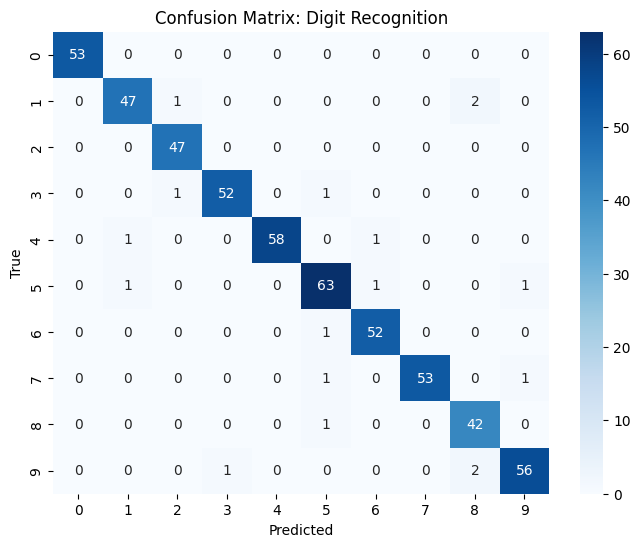

Top-2 Accuracy: 0.9907


In [12]:
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = LogisticRegression(max_iter=10000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)

print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred):.4f}")

# Confusion Matrix Heatmap
cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Digit Recognition')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Top-2 Accuracy
print(f"Top-2 Accuracy: {metrics.top_k_accuracy_score(y_test, y_probs, k=2):.4f}")

#### 🛠 Student Task 1
Compare `Top-2` and `Top-5` accuracy. Why does the score increase as `k` increases? Use the cell below to calculate Top-5.

Top-k Accuracy considera uma predição **correta** se a classe verdadeira estiver entre as `k` classes com maior probabilidade prevista pelo modelo.  
- Com `k=1`, apenas a classe com maior probabilidade deve ser a correta.  
- Com `k=2`, a classe correta pode ser a 1ª **ou** a 2ª mais provável.  
- Com `k=5`, o modelo tem 5 "tentativas", i.e em um problema de 10 dígitos, isso representa 50% das classes.  

Portanto, o score **sempre cresce (ou permanece igual) conforme `k` aumenta**, pois o conjunto de predições aceitas como corretas fica maior.  
No limite, quando `k = n classes`, o score é sempre 1.0.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:2051: UndefinedMetricWarning: 'k' (10) greater than or equal to 'n_classes' (10) will result in a perfect score and is therefore meaningless.
  warnings.warn(


|    k     |  Top-k Acc.   |
|    1     |    0.9685     |
|    2     |    0.9907     |
|    3     |    0.9963     |
|    5     |    1.0000     |
|    7     |    1.0000     |
|    10    |    1.0000     |


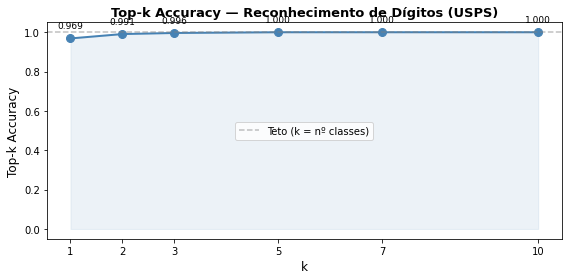


Top-5 Accuracy: 1.0000
  Interpretação: em 100.0% dos casos, o dígito correto está entre os 5 mais prováveis.


In [5]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

np.random.seed(42)
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = LogisticRegression(max_iter=10000)
clf.fit(X_train, y_train)
y_pred  = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)

# Comparação Top-k
k_values = [1, 2, 3, 5, 7, 10]
top_k_scores = [metrics.top_k_accuracy_score(y_test, y_probs, k=k) for k in k_values]

print("|    k     |  Top-k Acc.   |")
for k, score in zip(k_values, top_k_scores):
    print(f"|    {k:<5} |    {score:.4f}     |")

# Visualização
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, top_k_scores, marker='o', color='steelblue', linewidth=2, markersize=8)
ax.fill_between(k_values, top_k_scores, alpha=0.1, color='steelblue')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Teto (k = nº classes)')
for k, s in zip(k_values, top_k_scores):
    ax.annotate(f'{s:.3f}', (k, s), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('Top-k Accuracy', fontsize=12)
ax.set_title('Top-k Accuracy — Reconhecimento de Dígitos (USPS)', fontsize=13, fontweight='bold')
ax.set_xticks(k_values)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nTop-5 Accuracy: {metrics.top_k_accuracy_score(y_test, y_probs, k=5):.4f}")
print(f"  Interpretação: em {metrics.top_k_accuracy_score(y_test, y_probs, k=5)*100:.1f}% dos casos, "
      f"o dígito correto está entre os 5 mais prováveis.")

### Case 2: Medical Diagnosis (Mayo Clinic)
**Metric:** Precision, Recall, Specificity, F1.


In [10]:
data = load_breast_cancer()
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

 Threshold   Precision      Recall    F1-Score   FN (casos perdidos)
──────────────────────────────────────────────────────────────────────
       0.3      0.9636      0.9815      0.9725                     2 ← tarefa
       0.4      0.9636      0.9815      0.9725                     2
       0.5      0.9815      0.9815      0.9815                     2 ← padrão
       0.6      0.9813      0.9722      0.9767                     3
       0.7      0.9905      0.9630      0.9765                     4


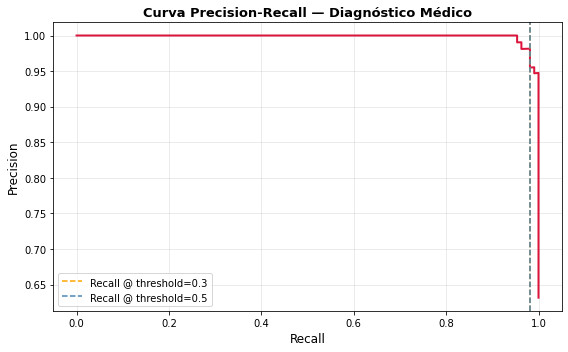

In [6]:
from sklearn.datasets import load_breast_cancer

data   = load_breast_cancer()
X, y   = data.data, data.target  # 0: Maligno, 1: Benigno
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = LogisticRegression(max_iter=10000).fit(X_train, y_train)

# Comparação entre thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
print(f"{'Threshold':>10}  {'Precision':>10}  {'Recall':>10}  {'F1-Score':>10}  {'FN (casos perdidos)':>20}")
print("─" * 70)

for t in thresholds:
    y_pred_t = (clf.predict_proba(X_test)[:, 1] >= t).astype(int)
    p  = metrics.precision_score(y_test, y_pred_t)
    r  = metrics.recall_score(y_test, y_pred_t)
    f1 = metrics.f1_score(y_test, y_pred_t)
    tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred_t).ravel()
    flag = " ← padrão" if t == 0.5 else (" ← tarefa" if t == 0.3 else "")
    print(f"{t:>10.1f}  {p:>10.4f}  {r:>10.4f}  {f1:>10.4f}  {fn:>20}{flag}")

# Curva Precision-Recall com matplotlib
prec_curve, rec_curve, thresh_curve = metrics.precision_recall_curve(y_test, clf.predict_proba(X_test)[:, 1])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_curve, prec_curve, color='crimson', linewidth=2)
ax.axvline(x=metrics.recall_score(y_test, (clf.predict_proba(X_test)[:, 1] >= 0.3).astype(int)),
            color='orange', linestyle='--', label='Recall @ threshold=0.3')
ax.axvline(x=metrics.recall_score(y_test, clf.predict(X_test)),
            color='steelblue', linestyle='--', label='Recall @ threshold=0.5')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curva Precision-Recall — Diagnóstico Médico', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### 🛠 Student Task 2
In medical screening, we want to maximize **Recall** (minimize False Negatives). Use `clf.predict_proba(X_test)` and a lower threshold (e.g., `0.3`) to generate new predictions. How do Precision and Recall change?

Ao **abaixar o threshold** (de 0.5 para 0.3), o modelo classifica mais casos como positivos (Benigno).  
- **Recall aumenta**: menos tumores malignos passam despercebidos (menos Falsos Negativos).  
- **Precision diminui**: mais casos benignos são incorretamente classificados como malignos (mais Falsos Positivos).

Em triagem médica, prefere-se **maximizar o Recall**: é menos prejudicial alertar um paciente saudável do que deixar uma condição clínica.


### Case 3: Fraud Detection (PayPal)
**Metric:** ROC-AUC.


In [ ]:
# High imbalance (2% fraud)
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.98, 0.02], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_probs = clf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = metrics.roc_curve(y_test, y_probs)
auc = metrics.auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Fraud Detection')
plt.legend()
plt.show()


#### 🛠 Student Task 3
Calculate the Accuracy of a model that simply predicts 'No Fraud' (0) for every single case. Compare it to the AUC. Which metric is more useful here?

Com 98% de casos legítimos, um modelo que **sempre responde "não é fraude"** acerta 98% das vezes produz Accuracy altíssima sem detectar **nenhuma fraude**.  

O AUC (Área sob a Curva ROC) mede a capacidade discriminativa real do modelo, sendo robusto ao desbalanceamento.  
**Conclusão:** Em datasets desbalanceados, Accuracy é uma métrica enganosa. AUC é muito mais informativa.

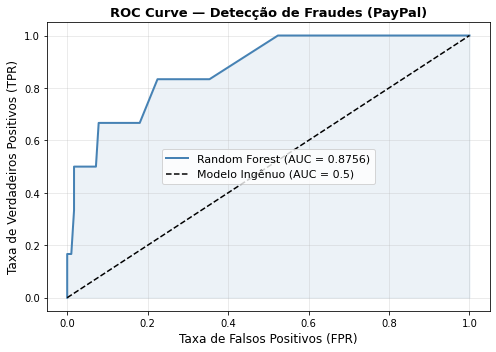

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.98, 0.02], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
y_probs = clf.predict_proba(X_test)[:, 1]

# Modelo ingênuo
y_naive = np.zeros(len(y_test), dtype=int)  # Sempre prevê "Sem Fraude"
naive_acc = metrics.accuracy_score(y_test, y_naive)

# Modelo real 
fpr, tpr, _ = metrics.roc_curve(y_test, y_probs)
auc = metrics.auc(fpr, tpr)
rf_acc = metrics.accuracy_score(y_test, clf.predict(X_test))
fraud_detected = metrics.recall_score(y_test, clf.predict(X_test))

# ROC com destaque em matpoltib
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.4f})', color='steelblue', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Modelo Ingênuo (AUC = 0.5)', linewidth=1.5)
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('ROC Curve — Detecção de Fraudes (PayPal)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Case 4 & 5: Fairness & Segmentation (Meta/NIH)
**Metric:** Macro/Micro/Weighted Averaging, Jaccard Score.


In [ ]:
# Multiclass reporting
X, y = make_classification(n_samples=1000, n_classes=3, weights=[0.7, 0.2, 0.1], n_informative=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(metrics.classification_report(y_test, y_pred))

# Jaccard (IoU)
mask_true = np.array([0, 1, 1, 0, 1])
mask_pred = np.array([0, 1, 0, 0, 1])
print(f"Jaccard Score: {metrics.jaccard_score(mask_true, mask_pred):.4f}")


#### 🛠 Student Task 4
If `mask_true = [1, 1, 0]` and `mask_pred = [1, 0, 0]`, calculate the IoU manually and then verify with code.

$$\text{IoU} = \frac{|A \cap B|}{|A \cup B|} = \frac{TP}{TP + FP + FN} = \frac{1}{1 + 0 + 1} = \frac{1}{2} = 0.5$$

Acertou 50% da sobreposição real entre máscara verdadeira e predita

TP=1, FP=0, FN=1
IoU Manual = 0.5000
IoU sklearn = 0.5000
Resultados coincidem!


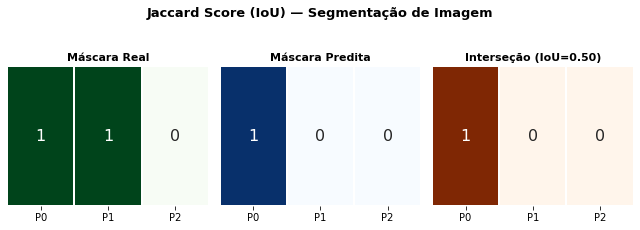

In [15]:
# Cálculo manual
mask_true = np.array([1, 1, 0])
mask_pred = np.array([1, 0, 0])

TP = np.sum((mask_true == 1) & (mask_pred == 1))
FP = np.sum((mask_true == 0) & (mask_pred == 1))
FN = np.sum((mask_true == 1) & (mask_pred == 0))

iou_manual = TP / (TP + FP + FN)
print(f"TP={TP}, FP={FP}, FN={FN}")
print(f"IoU Manual = {iou_manual:.4f}")

# Verificação com sklearn 
iou_sklearn = metrics.jaccard_score(mask_true, mask_pred)
print(f"IoU sklearn = {iou_sklearn:.4f}")
print(f"Resultados {'coincidem' if abs(iou_manual - iou_sklearn) < 1e-9 else 'divergem'}!")

# Visualização com matplolib para as máscaras
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
data_plot = [
    (mask_true.reshape(1, -1),  "Máscara Real",    'Greens'),
    (mask_pred.reshape(1, -1),  "Máscara Predita", 'Blues'),
    ((mask_true & mask_pred).reshape(1, -1), f"Interseção (IoU={iou_manual:.2f})", 'Oranges'),
]
for ax, (data, title, cmap) in zip(axes, data_plot):
    sns.heatmap(data, ax=ax, cmap=cmap, cbar=False, linewidths=2,
                linecolor='white', vmin=0, vmax=1, annot=True, fmt='d', annot_kws={"size": 16})
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_yticks([])
    ax.set_xticks([0.5, 1.5, 2.5])
    ax.set_xticklabels(['P0', 'P1', 'P2'])
plt.suptitle('Jaccard Score (IoU) — Segmentação de Imagem', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 🔸 Part 2: Regression Metrics


### Case 6: Real Estate Valuation (Zillow)
**Metric:** R2, MAE, MedAE, Explained Variance.


In [ ]:
housing = fetch_california_housing()
X, y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_test)

print(f"R2 Score: {metrics.r2_score(y_test, y_pred):.4f}")
print(f"MAE: {metrics.mean_absolute_error(y_test, y_pred):.4f}")
print(f"MedAE: {metrics.median_absolute_error(y_test, y_pred):.4f}")
print(f"Explained Variance: {metrics.explained_variance_score(y_test, y_pred):.4f}")


#### 🛠 Student Task 5
If the MAE is significantly higher than the MedAE, what does that suggest about 'outlier' errors in your house price predictions?

- **MAE** (Mean Absolute Error) é sensível a outliers — grandes erros inflam a média.  
- **MedAE** (Median Absolute Error) é robusto — representa o erro "típico", ignorando extremos.

Se `MAE >> MedAE`, significa que **existem algumas predições com erros muito grandes** (casas cujo preço foi muito subestimado ou superestimado), enquanto a maioria dos erros é pequena. É o mesmo efeito que vemos com média vs mediana de renda.

MAE   = 0.5272  (média dos erros absolutos)
MedAE = 0.4090  (mediana dos erros absolutos)
Razão MAE/MedAE = 1.29x

→ A diferença de 0.1183 indica a presença de outliers nas predições.


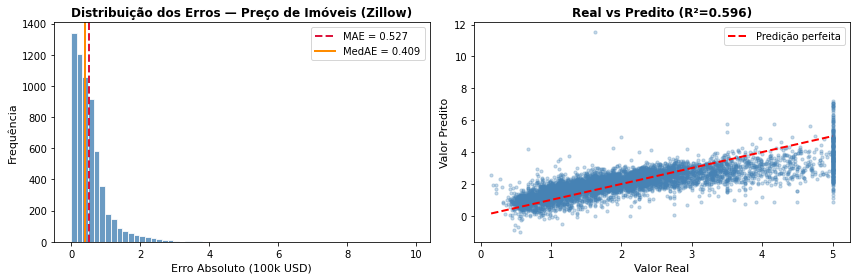

In [16]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

housing = fetch_california_housing()
X, y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_test)

mae   = metrics.mean_absolute_error(y_test, y_pred)
medae = metrics.median_absolute_error(y_test, y_pred)
r2    = metrics.r2_score(y_test, y_pred)

print(f"MAE   = {mae:.4f}  (média dos erros absolutos)")
print(f"MedAE = {medae:.4f}  (mediana dos erros absolutos)")
print(f"Razão MAE/MedAE = {mae/medae:.2f}x")
print(f"\n→ A diferença de {(mae-medae):.4f} indica a presença de outliers nas predições.")

# Distribuição dos erros absolutos
errors = np.abs(y_test - y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma dos erros
axes[0].hist(errors, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(mae,   color='crimson',  linewidth=2, linestyle='--', label=f'MAE = {mae:.3f}')
axes[0].axvline(medae, color='darkorange', linewidth=2, linestyle='-',  label=f'MedAE = {medae:.3f}')
axes[0].set_xlabel('Erro Absoluto (100k USD)', fontsize=11)
axes[0].set_ylabel('Frequência', fontsize=11)
axes[0].set_title('Distribuição dos Erros — Preço de Imóveis (Zillow)', fontsize=12, fontweight='bold')
axes[0].legend()

# Scatter real vs predito
axes[1].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Predição perfeita')
axes[1].set_xlabel('Valor Real', fontsize=11)
axes[1].set_ylabel('Valor Predito', fontsize=11)
axes[1].set_title(f'Real vs Predito (R²={r2:.3f})', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### Case 7: Energy Demand (GE) & Safety (Waymo)
**Metric:** MSE, MaxError.


In [ ]:
mse = metrics.mean_squared_error(y_test, y_pred)
max_e = metrics.max_error(y_test, y_pred)
print(f"MSE: {mse:.4f}")
print(f"Max Error: {max_e:.4f}")


#### 🛠 Student Task 6
Calculate the **RMSE** (Square root of MSE). Why is RMSE easier to interpret than MSE when talking to a client?

- **MSE** eleva os erros ao quadrado → a unidade resultante também fica ao quadrado (e.g., USD²).  
- **RMSE** é a raiz quadrada do MSE → **restaura a unidade original** (e.g., USD).  

Isso permite comparar o erro diretamente com os valores alvo. Dizer *"o modelo erra em média USD 60.000"* é muito mais intuitivo do que *"o MSE é 3.600.000.000 USD²"*.

MSE   = 0.5306  (unidade: 100k USD)², difícil de interpretar
RMSE  = 0.7284  (unidade: 100k USD), fácil de interpretar
Max Error = 9.8824  (pior predição individual)

Em valores absolutos (USD):
  RMSE     ≈ $72,840
  Max Err  ≈ $988,240


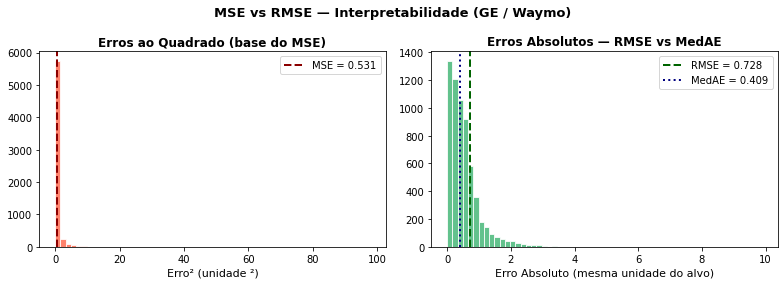

In [18]:
mse    = metrics.mean_squared_error(y_test, y_pred)
max_e  = metrics.max_error(y_test, y_pred)
rmse   = np.sqrt(mse)

print(f"MSE   = {mse:.4f}  (unidade: 100k USD)², difícil de interpretar")
print(f"RMSE  = {rmse:.4f}  (unidade: 100k USD), fácil de interpretar")
print(f"Max Error = {max_e:.4f}  (pior predição individual)")
print(f"\nEm valores absolutos (USD):")
print(f"  RMSE     ≈ ${rmse * 100_000:,.0f}")
print(f"  Max Err  ≈ ${max_e * 100_000:,.0f}")

# Comparação visual MSE vs RMSE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

errors = y_test - y_pred

# Erros ao quadrado (MSE)
axes[0].hist(errors**2, bins=60, color='tomato', edgecolor='white', alpha=0.8)
axes[0].axvline(mse, color='darkred', linewidth=2, linestyle='--', label=f'MSE = {mse:.3f}')
axes[0].set_xlabel('Erro² (unidade ²)', fontsize=11)
axes[0].set_title('Erros ao Quadrado (base do MSE)', fontsize=12, fontweight='bold')
axes[0].legend()

# Erros absolutos (RMSE)
axes[1].hist(np.abs(errors), bins=60, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[1].axvline(rmse,  color='darkgreen', linewidth=2, linestyle='--', label=f'RMSE = {rmse:.3f}')
axes[1].axvline(medae, color='navy',      linewidth=2, linestyle=':',  label=f'MedAE = {medae:.3f}')
axes[1].set_xlabel('Erro Absoluto (mesma unidade do alvo)', fontsize=11)
axes[1].set_title('Erros Absolutos — RMSE vs MedAE', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('MSE vs RMSE — Interpretabilidade (GE / Waymo)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Case 8: Relative Growth & Deviance (Shopify/AXA)
**Metric:** MSLE, MAPE, D2 Score.


In [ ]:
msle = metrics.mean_squared_log_error(y_test, np.maximum(y_pred, 0))
mape = metrics.mean_absolute_percentage_error(y_test, y_pred)
print(f"MSLE: {msle:.4f}")
print(f"MAPE: {mape:.4f} ({mape*100:.2f}%)")

try:
    d2 = metrics.d2_tweedie_score(y_test, y_pred)
    # Note: d2_pinball_score or d2_absolute_error_score are alternatives
    print(f"D2 Score: {d2:.4f}")
except AttributeError:
    print("D2 Score not available in this sklearn version.")


#### 🛠 Student Task 7
What happens to MAPE if some of your actual values (target) are zero? Why is this a major limitation of this metric?

$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100$$

Se `y_i = 0`, ocorre **divisão por zero**, o resultado é `inf` ou `NaN`.  
Mesmo valores muito próximos de zero explodem o percentual (e.g., erro de 0.01 com alvo 0.001, então MAPE de 1000%).

**Alternativas mais robustas:**
- **MSLE** (Mean Squared Log Error): lida bem com escalas multiplicativas.
- **MedAPE** (Median Absolute Percentage Error): menos sensível a zeros próximos.
- **MASE** (Mean Absolute Scaled Error): escalado por um baseline, sem divisão por zero.

Demonstração: MAPE com diferentes alvos próximos de zero
───────────────────────────────────────────────────────
  Caso normal (alvo=1.0)              → MAPE =      10.00%
  Alvo pequeno (0.1)                  → MAPE =      10.00%
  Alvo muito pequeno (0.01)           → MAPE =      10.00%
  Alvo = 0 (divisão por zero!)        → MAPE = 45035996273704960.00%

No dataset California Housing:
  MAPE = 31.75%  (inflado por algumas casas de baixo valor)
  MSLE = 0.0507   (penaliza subestimações, robusto a escala)


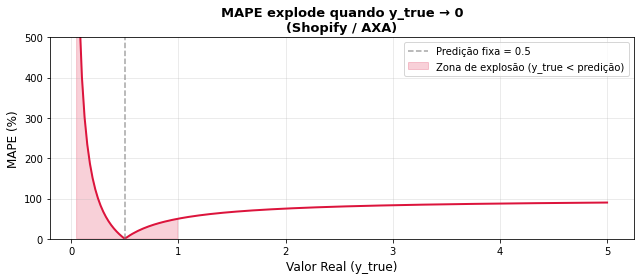

In [19]:
# ── Demonstração do problema de MAPE com zeros ───────────────────────────────
print("Demonstração: MAPE com diferentes alvos próximos de zero")
print("─" * 55)

test_cases = [
    ([1.0],  [0.9],  "Caso normal (alvo=1.0)"),
    ([0.1],  [0.09], "Alvo pequeno (0.1)"),
    ([0.01], [0.009],"Alvo muito pequeno (0.01)"),
    ([0.0],  [0.1],  "Alvo = 0 (divisão por zero!)"),
]

for y_true_ex, y_pred_ex, label in test_cases:
    try:
        mape_val = metrics.mean_absolute_percentage_error(y_true_ex, y_pred_ex)
        print(f"  {label:<35} → MAPE = {mape_val*100:>10.2f}%")
    except Exception as e:
        print(f"  {label:<35} → ERRO: {e}")

# ── Comparação MAPE, MSLE, MedAE em dados reais ──────────────────────────────
msle = metrics.mean_squared_log_error(y_test, np.maximum(y_pred, 0))
mape = metrics.mean_absolute_percentage_error(y_test, y_pred)

print(f"\nNo dataset California Housing:")
print(f"  MAPE = {mape*100:.2f}%  (inflado por algumas casas de baixo valor)")
print(f"  MSLE = {msle:.4f}   (penaliza subestimações, robusto a escala)")

# ── Visualização: como o erro percentual explode perto de zero ────────────────
y_true_range = np.linspace(0.05, 5, 200)
y_pred_fixed = np.ones(200) * 0.5   # predição fixa em 0.5
mape_range = np.abs((y_true_range - y_pred_fixed) / y_true_range) * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(y_true_range, mape_range, color='crimson', linewidth=2)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Predição fixa = 0.5')
ax.fill_between(y_true_range[y_true_range < 1], mape_range[y_true_range < 1],
                alpha=0.2, color='crimson', label='Zona de explosão (y_true < predição)')
ax.set_ylim(0, 500)
ax.set_xlabel('Valor Real (y_true)', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('MAPE explode quando y_true → 0\n(Shopify / AXA)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 🎯 Final Discussion: The PayPal Problem

> If you were PayPal, would you optimize **precision** or **recall**?

**Consider:**
- Cost of a False Positive (Blocking a legitimate $5,000 purchase).
- Cost of a False Negative (Allowing a $5,000 theft).


In [21]:
# Análise de custo: Precision vs Recall em Detecção de Fraudes

avg_transaction = 500   # valor médio de transação (USD)
daily_transactions = 1_000_000
fraud_rate = 0.002      # 0.2% de fraude

total_frauds  = int(daily_transactions * fraud_rate)
legit_trans   = daily_transactions - total_frauds

print("  PayPal: Análise de Custo — Precision vs Recall")
print(f"  Transações/dia:    {daily_transactions:,}")
print(f"  Taxa de fraude:    {fraud_rate*100:.1f}%  ({total_frauds:,} fraudes/dia)")
print(f"  Valor médio:       USD {avg_transaction}")
print()

scenarios = {
    "Alta Precision (FP baixo)":  {"precision": 0.95, "recall": 0.60},
    "Alto Recall (FN baixo)":     {"precision": 0.60, "recall": 0.95},
    "Balanceado (F1 otimizado)":  {"precision": 0.80, "recall": 0.80},
}

for name, s in scenarios.items():
    tp = total_frauds * s["recall"]
    fn = total_frauds * (1 - s["recall"])
    fp = tp / s["precision"] - tp  # de precision = tp/(tp+fp)

    custo_fn = fn * avg_transaction        # fraudes não detectadas → prejuízo total
    custo_fp = fp * avg_transaction * 0.02 # falsos alarmes → custo de análise manual (~2%)

    print(f"{name}")
    print(f"     Fraudes detectadas (TP):     {tp:,.0f}")
    print(f"     Fraudes perdidas (FN):       {fn:,.0f}  → Prejuízo: USD {custo_fn:,.0f}")
    print(f"     Alertas falsos (FP):         {fp:,.0f}  → Custo operacional: USD {custo_fp:,.0f}")
    print(f"     Custo total estimado:        USD {custo_fn + custo_fp:,.0f}")
    print()

  PayPal: Análise de Custo — Precision vs Recall
  Transações/dia:    1,000,000
  Taxa de fraude:    0.2%  (2,000 fraudes/dia)
  Valor médio:       USD 500

Alta Precision (FP baixo)
     Fraudes detectadas (TP):     1,200
     Fraudes perdidas (FN):       800  → Prejuízo: USD 400,000
     Alertas falsos (FP):         63  → Custo operacional: USD 632
     Custo total estimado:        USD 400,632

Alto Recall (FN baixo)
     Fraudes detectadas (TP):     1,900
     Fraudes perdidas (FN):       100  → Prejuízo: USD 50,000
     Alertas falsos (FP):         1,267  → Custo operacional: USD 12,667
     Custo total estimado:        USD 62,667

Balanceado (F1 otimizado)
     Fraudes detectadas (TP):     1,600
     Fraudes perdidas (FN):       400  → Prejuízo: USD 200,000
     Alertas falsos (FP):         400  → Custo operacional: USD 4,000
     Custo total estimado:        USD 204,000



Para o PayPal, RECALL é mais crítico.
Uma fraude não detectada (FN) representa perda de 100% do valor. Um alarme falso (FP) causa atrito ao usuário e custo operacional, mas é muito menor.

Na prática, busca-se o _threshold_ que minimiza o custo total = $C_{FN} \times FN + C_{FP} \times FP$.